# SKLearn

## SKLearn basics

### Importing libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import sklearn as sk
import catboost as cb
import lightgbm as lgbm
import xgboost as xgb
import seaborn as sns

In [10]:
from sklearn.datasets import fetch_california_housing

In [11]:
X, y = fetch_california_housing(
    return_X_y=True,
    as_frame=True
)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### KNN regressor

0.14434206676911643
0.5384657117277728


<Axes: xlabel='MedHouseVal'>

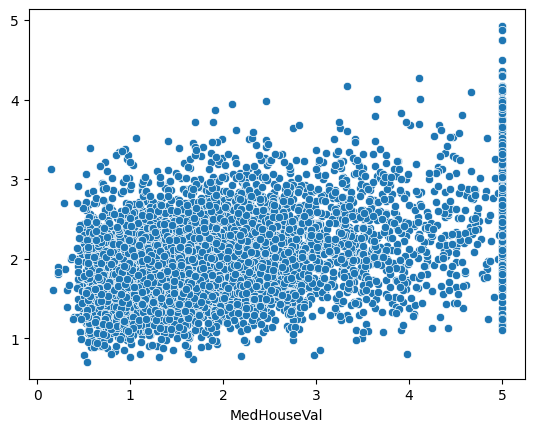

In [13]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X = X_train, y = y_train)
test_result = knn_regressor.predict(X_test)

print(r2_score(y_test, test_result))
print(mean_absolute_percentage_error(y_test, test_result))

sns.scatterplot(
    x = y_test,
    y = test_result
)


Linear regression shows much better results, which can be caused by different scale parameters in the data

### Linear regressor

Response type <class 'numpy.ndarray'>
R^2 score 0.5910509795491357
MAE score 0.3197837164612402


<Axes: xlabel='MedHouseVal'>

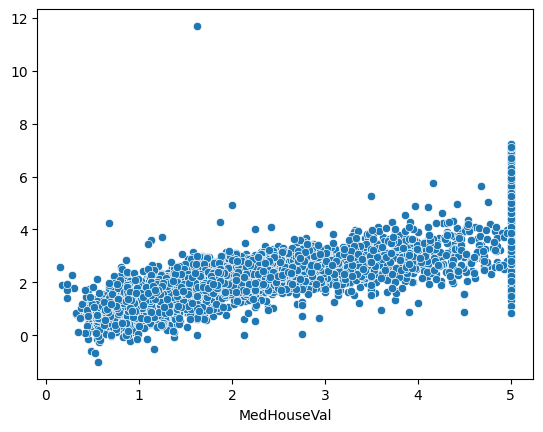

In [14]:
from sklearn.linear_model import LinearRegression
linear_regressor = LinearRegression()
linear_regressor.fit(X = X_train, y = y_train)
test_result = linear_regressor.predict(X_test)
print("Response type", type(test_result))
print("R^2 score", r2_score(y_test, test_result))
print("MAE score", mean_absolute_percentage_error(y_test, test_result))

sns.scatterplot(
    x = y_test,
    y = test_result
)


### Creating simple pipeline

Response type <class 'numpy.ndarray'>
R^2 score 0.6737569252627673
MAE score 0.2461425173697391


<Axes: xlabel='MedHouseVal'>

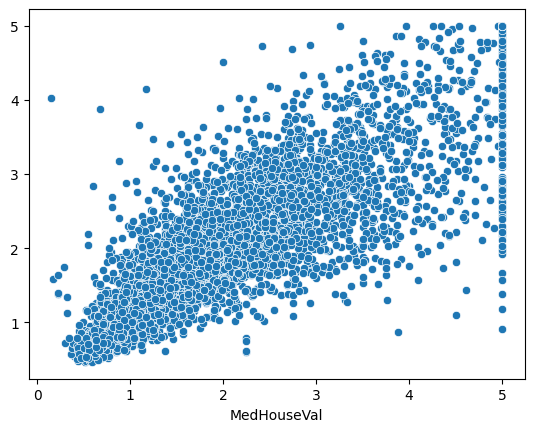

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, MinMaxScaler

pipeline = Pipeline(
    [
        ("scale", StandardScaler()),
        ("KNN regressor", KNeighborsRegressor())
    ]
)

pipeline.fit(
    X = X_train,
    y = y_train
)

test_result = pipeline.predict(X_test)

print("Response type", type(test_result))
print("R^2 score", r2_score(y_test, test_result))
print("MAE score", mean_absolute_percentage_error(y_test, test_result))
sns.scatterplot(
    x = y_test,
    y = test_result # type:ignore
)

In [16]:
print(test_result)

[0.4988   0.7646   4.750006 ... 1.3708   2.7464   3.979202]


### Creating simple GridSearch

In [17]:
pipeline.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()),
  ('KNN regressor', KNeighborsRegressor())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'KNN regressor': KNeighborsRegressor(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'KNN regressor__algorithm': 'auto',
 'KNN regressor__leaf_size': 30,
 'KNN regressor__metric': 'minkowski',
 'KNN regressor__metric_params': None,
 'KNN regressor__n_jobs': None,
 'KNN regressor__n_neighbors': 5,
 'KNN regressor__p': 2,
 'KNN regressor__weights': 'uniform'}

In [18]:
from sklearn.model_selection import GridSearchCV

grid_s = GridSearchCV(
    estimator=pipeline,
    param_grid={'KNN regressor__n_neighbors':list(range(20))},
    cv=3
)

In [19]:
grid_s.fit(X_train, y_train)
pd.DataFrame(grid_s.cv_results_).sort_values(by="rank_test_score")

KeyboardInterrupt: 

## Transformers and aggregators

In [ ]:
df_drawn = pd.read_csv(
    "drawndata1.csv"
)

df_drawn.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


<Axes: xlabel='x', ylabel='y'>

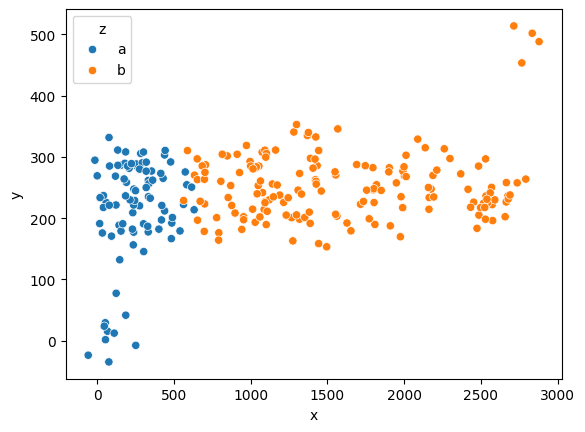

In [ ]:
sns.scatterplot(
    x = df_drawn.x,
    y = df_drawn.y,
    hue = df_drawn.z
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_drawn[["x", "y"]], df_drawn["z"])

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_new = pd.DataFrame(scaler.fit_transform(X_train))
X_train_new.columns = ["x", "y"]
X_test_new = pd.DataFrame(scaler.fit_transform(X_test))
X_test_new.columns = ["x", "y"]
y_train = pd.DataFrame(y_train)
y_train.columns = ["z"]

<Axes: xlabel='x', ylabel='y'>

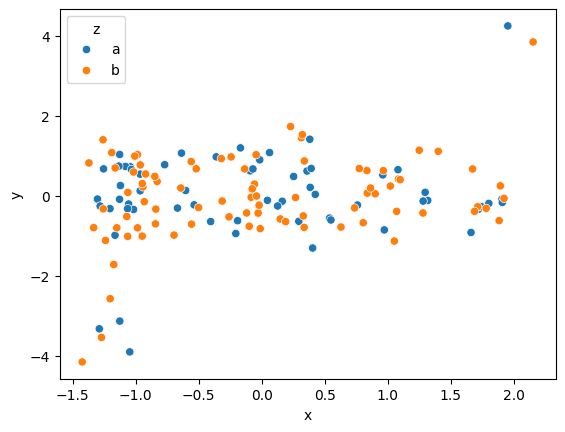

In [ ]:
sns.scatterplot(
    x = X_train_new.x,
    y = X_train_new.y,
    hue = y_train.z
)

<Axes: ylabel='Count'>

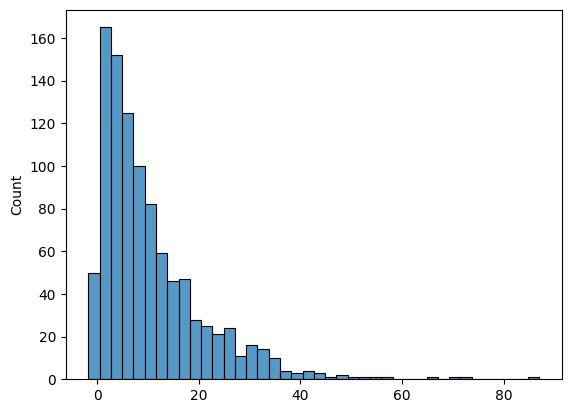

In [ ]:
x = np.random.exponential(
    10, 1000
) + np.random.normal(0, 1, 1000)

sns.histplot(x)

#### Normalize and standartize

<Axes: ylabel='Count'>

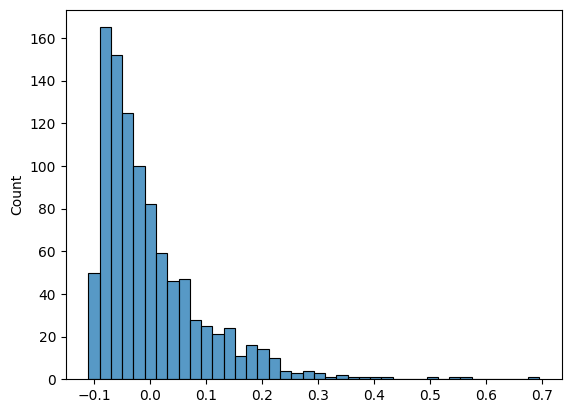

In [ ]:
sns.histplot((x - x.mean())/x.var())

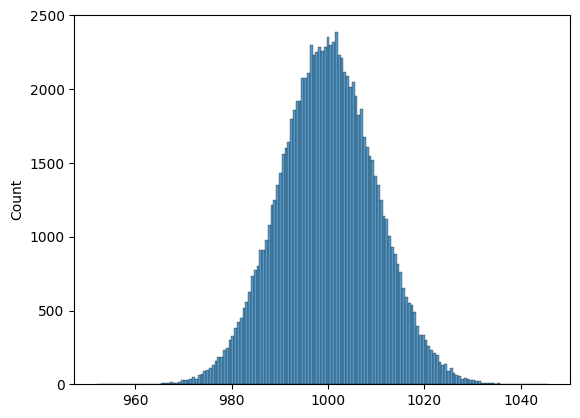

In [ ]:
def check_central_limith_theorem(n_samples = 10000, sample_size = 10000):
    sample_means = []
    for i in range(n_samples):
        sample = np.random.exponential(1000, sample_size)
        sample_means.append(sample.mean())
    sns.histplot(sample_means)
    plt.show()

check_central_limith_theorem(n_samples=100000)

<Axes: xlabel='x', ylabel='y'>

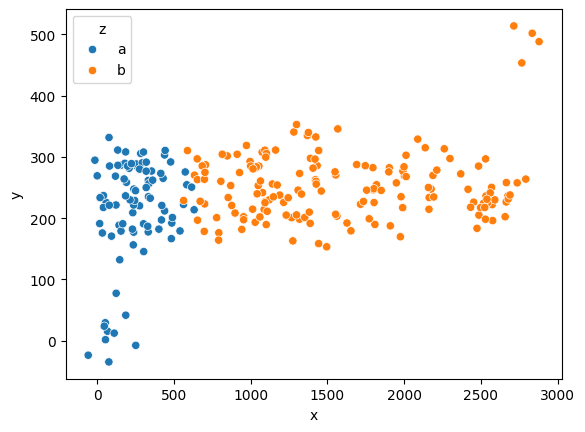

In [ ]:
sns.scatterplot(
    x = df_drawn.x,
    y = df_drawn.y,
    hue = df_drawn.z
)

/Users/karlkorhonen/проекты/Multi-tech projects/Django+AioGram/statistics_bot/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='x', ylabel='y'>

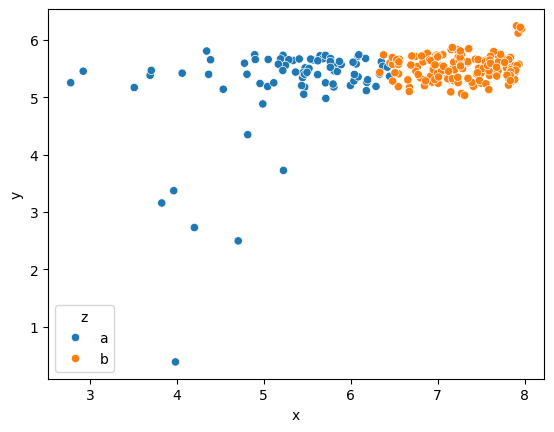

In [ ]:
sns.scatterplot(
    x = np.log(df_drawn.x),
    y = np.log(df_drawn.y),
    hue = df_drawn.z
)

### Quantile transformer

<Axes: >

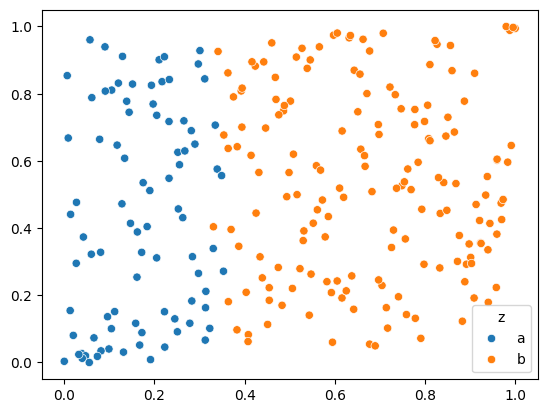

In [ ]:
X = df_drawn[["x", "y"]]
y = df_drawn["z"]

X_new = QuantileTransformer(n_quantiles=100).fit_transform(
    X
)

sns.scatterplot(
    x = X_new[:, 0],
    y = X_new[:, 1],
    hue = y
)

### Polinomial features

<Axes: xlabel='x', ylabel='y'>

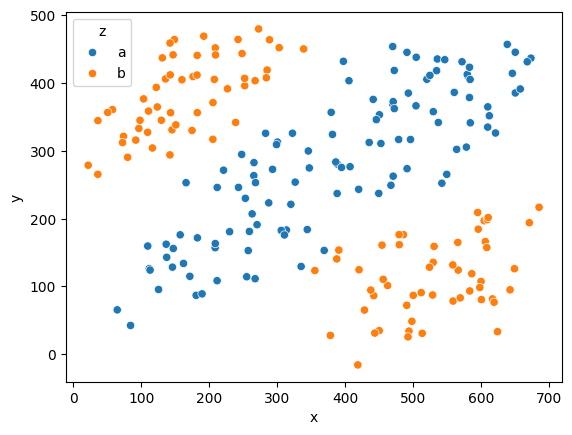

In [ ]:
df2 = pd.read_csv(
    "drawndata2.csv"
)

sns.scatterplot(
    x = df2.x,
    y = df2.y,
    hue = df2.z
)

<Axes: xlabel='x', ylabel='y'>

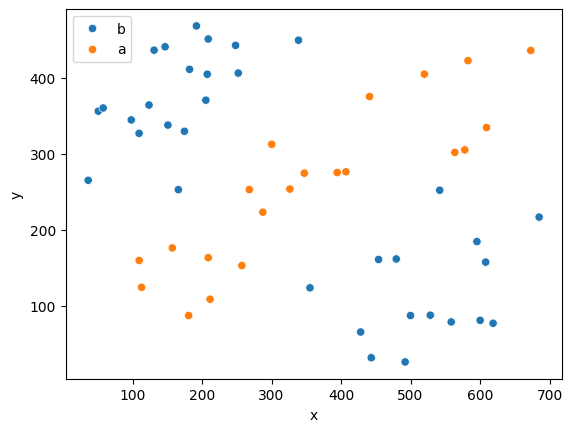

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

X_train_df2, X_test_df2, y_train_df2, y_test_df2 = train_test_split(df2[["x", "y"]], df2["z"], random_state=42)

pipeline_logreg = Pipeline(
    [
        ("features", PolynomialFeatures(
            degree=2
        )),
        ("logistic classifier", LogisticRegression())
    ]
).fit(
    X_train_df2,
    y_train_df2
)

y_predicted = pipeline_logreg.predict(
    X_test_df2
)

sns.scatterplot(
    x = X_test_df2.x,
    y = X_test_df2.y,
    hue = y_predicted
)

### One-Hot encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

values = np.random.choice(
    ["low", "high", "medium"],
    1000,
).reshape(-1, 1)
enc = OneHotEncoder(sparse_output=False)
pd.DataFrame(enc.fit_transform(values))

,0,1,2
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0
...,...,...,...
995,0.0,1.0,0.0
996,1.0,0.0,0.0
997,0.0,1.0,0.0
998,1.0,0.0,0.0


## SKLearn metrics

In [ ]:
credit_df = pd.read_csv(
    "creditcard.csv"
)

In [ ]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
X = credit_df[[col for col in credit_df.columns if col not in ("Time", "Class")]]
y = credit_df.Class

In [ ]:
print(y.sum())
print(X.shape)

492
(284807, 29)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    shuffle=True,
    random_state=43
)

X_test = pd.DataFrame(X_test)
X_test.columns = X.columns

X_train = pd.DataFrame(X_train)
X_train.columns = X.columns


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, precision_score
mod_log = LogisticRegression(
    max_iter = 1000,
    class_weight= {
        0:1,
        1:2
    }
)

mod.fit(
    X_train,
    y_train,
)

y_predicted = mod.predict(
    X_test
)

print("ROC_AUC score", roc_auc_score(
    y_true=y_test,
    y_score=y_predicted
))

print("Precision score", precision_score(
    y_true=y_test,
    y_pred=y_predicted
))

print("Recall score", recall_score(
    y_true=y_test,
    y_pred=y_predicted
))

mod_log.get_params()



ROC_AUC score 0.8305890694370205
Precision score 0.8316831683168316
Recall score 0.6614173228346457


{'C': 1.0,
 'class_weight': {0: 1, 1: 2},
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 1000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

### Creating custom scorers

In [ ]:
from sklearn.metrics import f1_score, make_scorer
grid_log = GridSearchCV(
    estimator=mod_log,
    param_grid={'class_weight':[{0: 1, 1: i} for i in np.linspace(1, 20, 40)]},
    cv=10,
    scoring = {
        'precision':make_scorer(precision_score),
        'recall':make_scorer(recall_score),
        'f1_score':make_scorer(f1_score),
        "roc_auc score":make_scorer(roc_auc_score)
    },
    refit="recall",
    n_jobs=-1
)
grid_log.fit(X_train, y_train)
pd.DataFrame(grid_s.cv_results_).sort_values(by="rank_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_KNN regressor__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
10,0.003375,0.000149,0.105809,0.002895,10,{'KNN regressor__n_neighbors': 10},0.676904,0.707831,0.673406,0.686047,0.015470,1
7,0.003636,0.000373,0.096498,0.003182,7,{'KNN regressor__n_neighbors': 7},0.674786,0.707211,0.673157,0.685051,0.015683,2
11,0.003337,0.000054,0.108670,0.002745,11,{'KNN regressor__n_neighbors': 11},0.674313,0.707560,0.672738,0.684870,0.016057,3
8,0.003498,0.000286,0.099844,0.003573,8,{'KNN regressor__n_neighbors': 8},0.675586,0.707463,0.671360,0.684803,0.016115,4
9,0.003482,0.000208,0.102948,0.002307,9,{'KNN regressor__n_neighbors': 9},0.675480,0.707005,0.670791,0.684425,0.016081,5
12,0.003271,0.000105,0.111109,0.003205,12,{'KNN regressor__n_neighbors': 12},0.673149,0.706857,0.673215,0.684407,0.015875,6
13,0.003283,0.000107,0.114436,0.003155,13,{'KNN regressor__n_neighbors': 13},0.672507,0.706175,0.673812,0.684165,0.015573,7
14,0.003303,0.000047,0.117142,0.003983,14,{'KNN regressor__n_neighbors': 14},0.672065,0.706261,0.672609,0.683645,0.015993,8
15,0.003356,0.000110,0.119335,0.003161,15,{'KNN regressor__n_neighbors': 15},0.672199,0.704690,0.672716,0.683201,0.015196,9
6,0.003221,0.000060,0.092272,0.004236,6,{'KNN regressor__n_neighbors': 6},0.671568,0.706498,0.669902,0.682656,0.016872,10


## Meta Models

### Voting classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.datasets import make_classification

<Axes: >

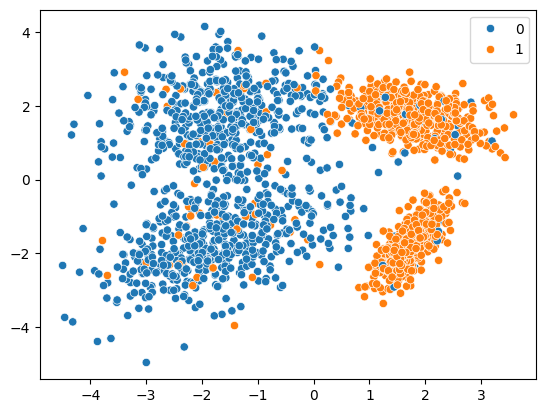

In [ ]:
X, y = make_classification(
    n_samples=2000,
    n_features=2,
    n_redundant=0,
    random_state=21,
    class_sep=1.75,
    flip_y=0.1
)

X_train, X_test, y_train, y_test = train_test_split(X, y)

sns.scatterplot(
    x = X[:, 0],
    y = X[:, 1],
    hue = y
)

In [ ]:
clf1 = LogisticRegression().fit(X, y)
clf2 = KNeighborsClassifier().fit(X, y)
clf3 = VotingClassifier(
    estimators=[
        ("clf1", clf1),
        ("clf2", clf2),
    ],
    weights=[10.5, 2.5]
)

In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
pol = PolynomialFeatures()
pol.get_params()

{'degree': 2, 'include_bias': True, 'interaction_only': False, 'order': 'C'}

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
rd = Ridge()
rd.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

kn = KNeighborsRegressor()
kn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.get_params()

{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'squared_error',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()
rfr.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [20]:
import pandas as pd

In [21]:
df777 = pd.read_csv("tech.csv")

In [24]:
df777

,Аналитическое мышление
0,Сегментирование аудитории
1,SQL
2,CTE
3,витрины данных
4,Python
...,...
124,метрики
125,Superset
126,Tableau
127,PowerBI


In [27]:
df777["Аналитическое мышление"] = df777["Аналитическое мышление"].apply(lambda x: x.strip().lower())

In [30]:
pd.set_option('display.max_rows', None)
pd.DataFrame(df777.value_counts())

,count
Аналитическое мышление,
sql,11
python,7
a/b тесты,6
продуктовые метрики,6
ml,4
powerbi,4
математическая статистика,4
superset,4
tableau,4


In [13]:
from sklearn.datasets import fetch_california_housing, load_diabetes, make_regression
import pandas as pd
data = fetch_california_housing(as_frame=True)
# data.frame уже содержит все данные
df_ch = pd.DataFrame(data.frame) 
df_ch.to_csv("regression.csv")